<a href="https://colab.research.google.com/github/Saisha0512/Loan_Prediction_Model/blob/main/Loan_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loan Prediction Model**

# **Importing the Libraries**

In [1]:
# Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

# **Loading Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Projects Datasets/loan_prediction_dataset.csv')

# **Analysing the Data**

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [20]:
# Column Names :
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [21]:
# DataFrame Shape :
df.shape

(614, 12)

In [22]:
# Information of the dataframe :
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [23]:
# Checking for missing values :
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [24]:
# Number of unique values in each column :
df.nunique()

,0
Gender,2
Married,2
Dependents,4
Education,2
Self_Employed,2
ApplicantIncome,505
CoapplicantIncome,287
LoanAmount,204
Loan_Amount_Term,11
Credit_History,3


# **Data Preprocessing**

In [10]:
# Dropping the unecessary columns :
df.drop(['Loan_ID'], axis = 1, inplace = True)

In [11]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [12]:
df.shape

(614, 12)

In [25]:
# Filling the missing values :
cat = df.select_dtypes(include = 'object').columns
num = df.select_dtypes(include = 'number').columns

# Handling the missing values for Categorical Columns :
for col in cat :
  if (df[col].isnull().sum() > 0) :
    df[col].fillna(df[col].mode()[0], inplace = True)

# Hnadling the missing values for Numerical Columns :
for col in num :
  if (df[col].isnull().sum() > 0) :
    df[col].fillna(df[col].mean(), inplace = True)

In [26]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [27]:
df.sample(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
281,Male,Yes,0,Graduate,No,3927,800.0,112.0,360.0,1.0,Semiurban,Y
492,Male,No,0,Not Graduate,No,3691,0.0,110.0,360.0,1.0,Rural,Y
521,Male,No,0,Graduate,No,2500,0.0,55.0,360.0,1.0,Semiurban,Y
108,Male,Yes,2,Graduate,No,3800,3600.0,216.0,360.0,0.0,Urban,N
389,Male,Yes,0,Graduate,No,5488,0.0,125.0,360.0,1.0,Rural,Y


In [28]:
# Encoding the categorical values to the numerical values :

# **Exploratory Data Analysis (EDA)**

In [29]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [31]:
df.sample(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
187,Male,Yes,0,Graduate,No,2383,2138.0,58.0,360.0,0.842199,Rural,Y
108,Male,Yes,2,Graduate,No,3800,3600.0,216.0,360.0,0.000000,Urban,N
381,Male,No,0,Graduate,No,5941,4232.0,296.0,360.0,1.000000,Semiurban,Y
233,Female,No,0,Graduate,No,8333,0.0,280.0,360.0,1.000000,Semiurban,Y
500,Female,No,0,Graduate,No,645,3683.0,113.0,480.0,1.000000,Rural,Y


**Gender**

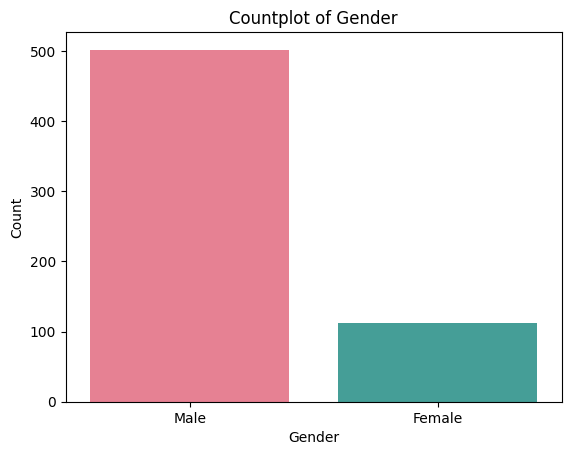

In [32]:
# Countplot to count the no. of applicants according to gender :
sns.countplot(x = df['Gender'], data = df, palette = 'husl')
plt.title('Countplot of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

**Married**

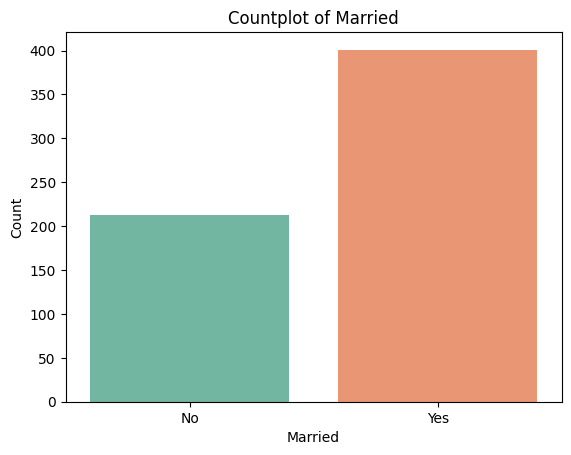

In [34]:
# Countplot to count the no. of applicants married :
sns.countplot(x = df['Married'], data = df, palette = 'Set2')
plt.title('Countplot of Married')
plt.xlabel('Married')
plt.ylabel('Count')
plt.show()

**Dependents**

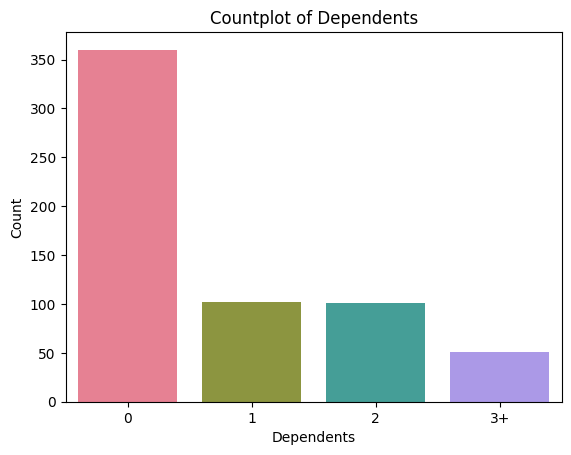

In [38]:
# Countplot to display the distibution of dependents :
sns.countplot(x = df['Dependents'], data = df, palette = 'husl')
plt.title('Countplot of Dependents')
plt.xlabel('Dependents')
plt.ylabel('Count')
plt.show()

**Education**

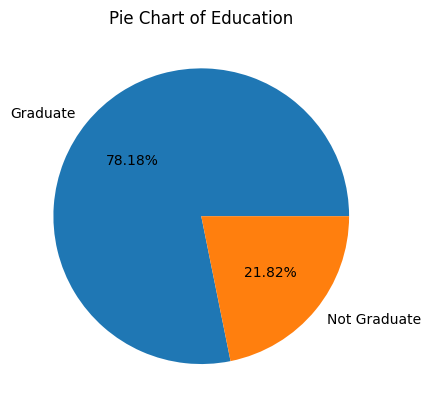

In [43]:
# Pie chart to disply the ratio of applicants based on Education :
plt.pie(df['Education'].value_counts(), labels = df['Education'].value_counts().index, autopct = '%1.2f%%')
plt.title('Pie Chart of Education')
plt.show()

**Self - Employed**

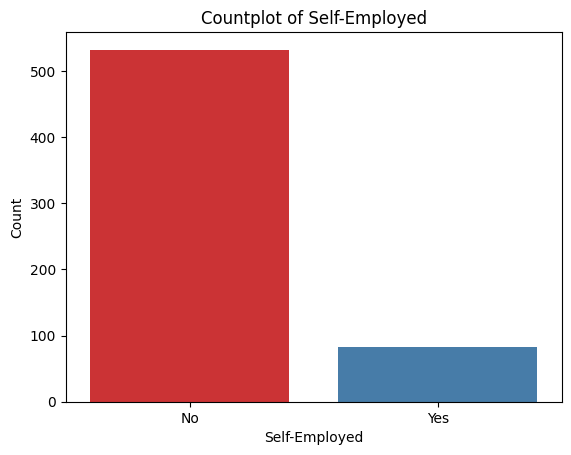

In [45]:
# Countplot to display the ratio of applicants that are Self-Employed :
sns.countplot(x = df['Self_Employed'], data = df, palette = 'Set1')
plt.title('Countplot of Self-Employed')
plt.xlabel('Self-Employed')
plt.ylabel('Count')
plt.show()

**Applicant_Income**

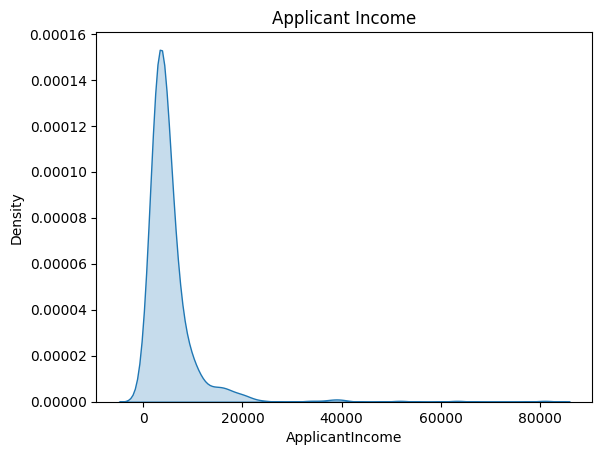

In [49]:
# Graph for Applicant Income :
sns.kdeplot(df['ApplicantIncome'], fill = True)
plt.title('Applicant Income')
plt.show()

**Loan Amount vs Applicant Income**

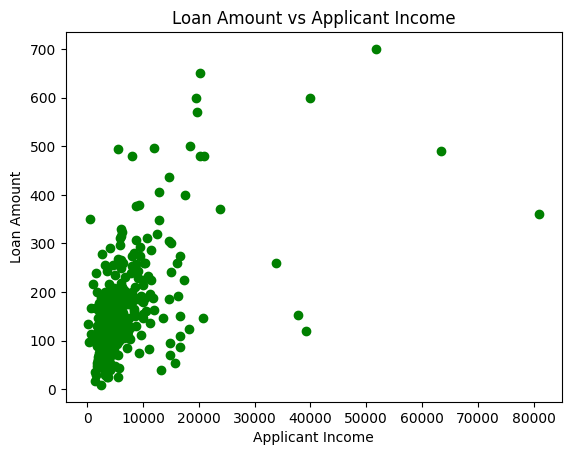

In [54]:
# Scatter Plot to display Loan Amount vs Applicant Income :
plt.scatter(x = df['ApplicantIncome'], y = df['LoanAmount'], color = 'green')
plt.title('Loan Amount vs Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.show()

**Credit History Impact**

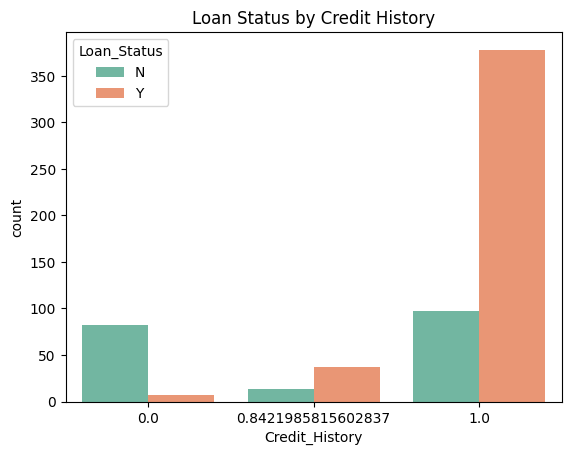

In [56]:
# Barplot to display the impact of Applicant's Credit History :
sns.countplot(data=df, x="Credit_History", hue="Loan_Status", palette="Set2")
plt.title("Loan Status by Credit History")
plt.show()

**Dependents vs Loan Approval**

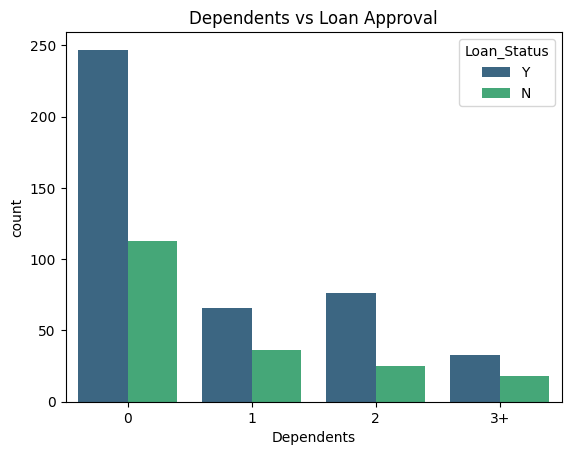

In [57]:
# Plot to display the relationship between Dependents & Loan Approval :
sns.countplot(data=df, x="Dependents", hue="Loan_Status", palette="viridis")
plt.title("Dependents vs Loan Approval")
plt.show()

# **Data Preprocessing**